# Разметка ЭКГ эксперимента 3

**Статус:** активный производитель кандидатных и принятых вручную R-зубцов для
записей РНЦХ. Автоматическая детекция не создаёт проверенную ЭКГ-разметку.

ЭКГ задаёт временную привязку сердечных циклов и не локализует источник
биоимпедансного сигнала. Для записи `14-19-52` текущий порог $2\sigma$
пропускает восемь морфологически сходных событий на участке 36–47 с.
Диагностический порог $1\sigma$ восстанавливает непрерывную последовательность
из 88 кандидатов, но этот результат остаётся `pending_manual_review` и не
считается принятой R-разметкой. Для трёх остальных записей добавлены сегментные
маски: частично пригодные участки `exp03_ttrkg_only`, полное исключение ЭКГ
`exp03_side_only` и технические переходы `exp03_switch_test`.

## Входы и научный статус

Набор записей задаётся полем `annotation_targets` внешней конфигурации.
Кандидатная ЭКГ-разметка строится непосредственно по исходному CSV и не зависит
от принятия дыхательных интервалов. Если для записи существует дыхательный
sidecar из [`11.11`](11.11_Разметка_дыхания_эксперимента_3.ipynb), его
происхождение и текущий статус записываются как сопроводительная информация.
Отсутствующий или непринятый дыхательный sidecar не блокирует ручную проверку
ЭКГ.

Совместный последующий анализ остаётся закрытым, пока независимо не приняты и
дыхательная, и ЭКГ-разметка. Такая развязка не позволяет одной ручной процедуре
неявно принять результат другой.

Связь всех имеющихся входов проверяется по полному SHA-256. Полярность ЭКГ
выбирается алгоритмом как диагностическое решение и затем проверяется
человеком. Основной порог детекции берётся из конфигурации. Дополнительно
строится более широкий кандидатный набор с половинным порогом по высоте; он
служит только для поиска возможных пропусков и не подменяет ручную разметку.

Расчётное окно электрической систолы строится по рабочей модели

$$
QT=QT_c\sqrt{RR},
$$

где $QT$ — расчётная продолжительность модельного окна; $RR$ — интервал между
соседними принятыми R-зубцами; $QT_c$ — заданный модельный параметр. Это окно
не является измеренной QT-разметкой, механической систолой или клапанным
событием.

In [1]:
# Импорты и внешний контракт данных
from datetime import datetime, timezone
import hashlib
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

CONFIG_ENV = "KALMYKOV_EXP03_CONFIG"
config_value = os.environ.get(CONFIG_ENV)
if not config_value:
    raise RuntimeError(
        f"Задайте {CONFIG_ENV}: путь к локальному JSON по схеме "
        "config/exp03_paths.example.json"
    )
CONFIG_PATH = Path(config_value).expanduser().resolve()
CONFIG = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
DATA_ROOT = Path(CONFIG["data_root"]).expanduser().resolve()
DERIVED_ROOT = Path(CONFIG["derived_root"]).expanduser().resolve()
CSV_ROOT = (DATA_ROOT / CONFIG["csv_subdir"]).resolve()
CSV_ROOT.relative_to(DATA_ROOT)
BREATHING_DIR = DERIVED_ROOT / "exp03" / "annotations" / "breathing"
OUT_DIR = DERIVED_ROOT / "exp03" / "annotations" / "ecg"
OUT_DIR.mkdir(parents=True, exist_ok=True)

recording_items = CONFIG["recordings"]
record_ids = [item["record_id"] for item in recording_items]
if not recording_items or len(record_ids) != len(set(record_ids)):
    raise ValueError("recordings должен содержать уникальные record_id")
ECG_RECORDINGS = [
    item for item in recording_items if "ecg" in item.get("annotation_targets", [])
]

SOURCE_COLUMNS = CONFIG["source_columns"]
CANONICAL_COLUMNS = [
    "time_s", "rheo_1_mohm", "base_1_ohm", "qs_1_ohm",
    "ecg_v", "rheo_2_mohm", "base_2_ohm", "qs_2_ohm",
]
if len(SOURCE_COLUMNS) != len(CANONICAL_COLUMNS):
    raise ValueError("source_columns должен описывать восемь столбцов CSV")

PARAMETERS = {
    key: float(value) for key, value in CONFIG["ecg_detection"].items()
}
REQUIRED_PARAMETERS = {
    "low_hz", "high_hz", "filter_order", "min_rr_s", "peak_height_z",
    "peak_prominence_z", "refine_half_window_s", "qtc_s", "q_lead_s",
    "min_rr_for_qt_s", "default_rr_s",
}
if set(PARAMETERS) != REQUIRED_PARAMETERS:
    raise ValueError("ecg_detection должен содержать полный набор параметров")
for name, value in PARAMETERS.items():
    if not np.isfinite(value) or value <= 0:
        raise ValueError(f"Параметр {name} должен быть положительным")

ALGORITHM_VERSION = "exp03-ecg-rpeak-v4-segmented-review"
DIAGNOSTIC_HEIGHT_FACTOR = 0.5
LONG_RR_THRESHOLD_S = 1.5
MANUAL_REVIEW_FOCUS_S = {"exp03_both_breathing": [36.0, 47.0]}
SEGMENTED_REVIEW_GUIDANCE = {
    "exp03_ttrkg_only": {
        "status": "partially_usable_pending_manual_review",
        "usable_segments": [
            {
                "start_s": 0.5,
                "stop_s": 30.0,
                "candidate_source": "primary",
                "basis": "38 strict candidates; median RR 0.80 s; RR CV 0.157",
            },
            {
                "start_s": 40.0,
                "stop_s": 49.0,
                "candidate_source": "diagnostic_lower_threshold",
                "basis": "11 candidates; median RR 0.82 s; RR CV 0.066",
            },
            {
                "start_s": 55.0,
                "stop_s": 67.2,
                "candidate_source": "diagnostic_lower_threshold",
                "basis": "17 candidates; median RR 0.74 s; RR CV 0.033",
            },
        ],
        "exclude_intervals_s": [
            [32.700, 34.460],
            [37.300, 39.300],
            [50.750, 55.200],
        ],
        "limitations": [
            "continuous_whole_record_rpeak_series_is_not_authorized",
            "candidate_segments_require_manual_waveform_review",
        ],
    },
    "exp03_side_only": {
        "status": "exclude_entire_record_from_ecg_analysis",
        "usable_segments": [],
        "exclude_intervals_s": [[0.000, 69.220]],
        "limitations": [
            "slow_sawtooth_like_ecg_field_without_stable_qrs_complexes",
            "filtered_candidates_are_dominated_by_responses_to_slope_breaks",
            "this_exclusion_applies_to_ecg_not_automatically_to_side_rheography",
        ],
    },
    "exp03_switch_test": {
        "status": "global_candidates_match_technical_transitions",
        "usable_segments": [],
        "transition_intervals_s": [
            [11.565, 11.605],
            [23.485, 23.565],
            [33.565, 33.625],
            [43.245, 43.285],
        ],
        "saturation_intervals_s": [
            [11.600, 11.840],
            [23.560, 24.285],
            [33.620, 34.080],
            [43.280, 43.760],
        ],
        "exclude_intervals_s": [
            [11.565, 25.700],
            [33.565, 36.200],
            [43.245, 46.020],
        ],
        "limitations": [
            "four_primary_candidates_are_technical_events_not_rpeaks",
            "global_polarity_is_distorted_by_switching_transients",
            "local_negative_polarity_search_requires_separate_manual_review",
        ],
    },
}


def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def resolve_record_path(relative_path):
    path = (DATA_ROOT / relative_path).resolve()
    path.relative_to(CSV_ROOT)
    if not path.is_file():
        raise FileNotFoundError(f"Нет файла для записи: {relative_path}")
    return path


def read_record(path):
    frame = pd.read_csv(path)
    if list(frame.columns) != SOURCE_COLUMNS:
        raise ValueError("Схема CSV не совпадает с source_columns")
    frame.columns = CANONICAL_COLUMNS
    frame = frame.apply(pd.to_numeric, errors="raise")
    if len(frame) < 2 or not np.isfinite(frame.to_numpy(dtype=float)).all():
        raise ValueError("CSV пуст, слишком короток или содержит нечисловые значения")
    return frame


def sampling_frequency(frame):
    time = frame["time_s"].to_numpy(dtype=float)
    delta = np.diff(time)
    if len(delta) == 0 or np.any(~np.isfinite(delta)) or np.any(delta <= 0):
        raise ValueError("time_s должен быть конечным и строго возрастающим")
    median_dt = float(np.median(delta))
    jitter_fraction = float(np.median(np.abs(delta - median_dt)) / median_dt)
    return 1.0 / median_dt, jitter_fraction

In [2]:
# Детекция R-зубцов, диагностический набор и модельное окно электрической систолы
def filtered_ecg(ecg_signal, fs_hz, parameters=PARAMETERS):
    low_hz = parameters["low_hz"]
    high_hz = parameters["high_hz"]
    nyquist_hz = fs_hz / 2.0
    if not 0 < low_hz < high_hz < nyquist_hz:
        raise ValueError("Полоса ЭКГ должна находиться ниже частоты Найквиста")
    order = int(parameters["filter_order"])
    if order < 1 or order != parameters["filter_order"]:
        raise ValueError("filter_order должен быть положительным целым")
    b, a = butter(
        order,
        [low_hz / nyquist_hz, high_hz / nyquist_hz],
        btype="band",
    )
    raw = np.asarray(ecg_signal, dtype=float)
    if len(raw) <= 3 * max(len(a), len(b)) or not np.isfinite(raw).all():
        raise ValueError("ЭКГ слишком короткая или содержит нечисловые значения")
    filtered = filtfilt(b, a, raw)
    scale = float(np.std(filtered))
    if not np.isfinite(scale) or scale <= np.finfo(float).eps:
        raise ValueError("После фильтрации отсутствует вариабельность ЭКГ")
    normalized = filtered / scale
    positive_strength = float(np.percentile(normalized, 99.5))
    negative_strength = float(np.percentile(-normalized, 99.5))
    polarity = 1 if positive_strength >= negative_strength else -1
    return raw, normalized, int(polarity)


def detect_rpeaks(
    ecg_signal,
    fs_hz,
    parameters=PARAMETERS,
    peak_height_z=None,
):
    raw, normalized, polarity = filtered_ecg(ecg_signal, fs_hz, parameters)
    height_z = (
        parameters["peak_height_z"]
        if peak_height_z is None
        else float(peak_height_z)
    )
    if not np.isfinite(height_z) or height_z <= 0:
        raise ValueError("peak_height_z должен быть положительным")
    candidates, properties = find_peaks(
        polarity * normalized,
        distance=max(1, int(round(parameters["min_rr_s"] * fs_hz))),
        height=height_z,
        prominence=parameters["peak_prominence_z"],
    )
    half_window = max(
        1, int(round(parameters["refine_half_window_s"] * fs_hz))
    )
    signed_raw = polarity * raw
    events_by_refined_index = {}
    for position, candidate in enumerate(candidates):
        start = max(0, candidate - half_window)
        stop = min(len(raw), candidate + half_window + 1)
        refined_index = start + int(np.argmax(signed_raw[start:stop]))
        event = {
            "filtered_index": int(candidate),
            "refined_index": int(refined_index),
            "filtered_height_z": float(polarity * normalized[candidate]),
            "prominence_z": float(properties["prominences"][position]),
            "refinement_shift_samples": int(refined_index - candidate),
        }
        previous = events_by_refined_index.get(refined_index)
        if (
            previous is None
            or event["filtered_height_z"] > previous["filtered_height_z"]
        ):
            events_by_refined_index[refined_index] = event
    refined = np.asarray(sorted(events_by_refined_index), dtype=int)
    events = [events_by_refined_index[int(index)] for index in refined]
    return refined, polarity, normalized, events


def candidate_rr_qc(rpeaks_s, duration_s):
    values = np.asarray(rpeaks_s, dtype=float)
    rr_s = np.diff(values)
    long_gaps = [
        {
            "start_s": float(left),
            "stop_s": float(right),
            "duration_s": float(right - left),
        }
        for left, right in zip(values[:-1], values[1:])
        if right - left >= LONG_RR_THRESHOLD_S
    ]
    return {
        "count": int(len(values)),
        "count_rate_bpm": float(len(values) / duration_s * 60.0),
        "median_rr_s": float(np.median(rr_s)) if len(rr_s) else None,
        "minimum_rr_s": float(np.min(rr_s)) if len(rr_s) else None,
        "maximum_rr_s": float(np.max(rr_s)) if len(rr_s) else None,
        "rr_cv": (
            float(np.std(rr_s, ddof=1) / np.mean(rr_s))
            if len(rr_s) > 1
            else None
        ),
        "long_gaps_ge_1_5_s": long_gaps,
    }


def template_correlations(signed_filtered, peak_indices, fs_hz):
    left = int(round(0.18 * fs_hz))
    right = int(round(0.25 * fs_hz))
    valid_indices = [
        int(index)
        for index in peak_indices
        if index - left >= 0 and index + right < len(signed_filtered)
    ]
    if len(valid_indices) < 3:
        return {}
    segments = np.asarray([
        signed_filtered[index - left:index + right + 1]
        for index in valid_indices
    ])
    template = np.median(segments, axis=0)
    result = {}
    for index, segment in zip(valid_indices, segments):
        if np.std(segment) <= np.finfo(float).eps:
            result[index] = None
        else:
            value = float(np.corrcoef(segment, template)[0, 1])
            result[index] = value if np.isfinite(value) else None
    return result


def model_electrical_systole(rpeaks_s, parameters=PARAMETERS):
    windows = []
    rpeaks_s = np.asarray(rpeaks_s, dtype=float)
    for index, r_time in enumerate(rpeaks_s):
        if index + 1 < len(rpeaks_s):
            rr_s = rpeaks_s[index + 1] - r_time
        elif index > 0:
            rr_s = r_time - rpeaks_s[index - 1]
        else:
            rr_s = parameters["default_rr_s"]
        qt_s = parameters["qtc_s"] * np.sqrt(
            max(rr_s, parameters["min_rr_for_qt_s"])
        )
        q_start_s = r_time - parameters["q_lead_s"]
        windows.append([float(q_start_s), float(q_start_s + qt_s)])
    return windows

In [3]:
# Формирование независимых ЭКГ-sidecar-файлов
def segmented_review_payload(record_id, primary_rpeaks_s, diagnostic_rpeaks_s):
    guidance = SEGMENTED_REVIEW_GUIDANCE.get(record_id)
    if guidance is None:
        return None
    result = json.loads(json.dumps(guidance, ensure_ascii=False))
    for segment in result.get("usable_segments", []):
        source = segment["candidate_source"]
        values = (
            primary_rpeaks_s
            if source == "primary"
            else diagnostic_rpeaks_s
        )
        segment["candidate_rpeaks_s"] = [
            float(value)
            for value in values
            if segment["start_s"] <= value <= segment["stop_s"]
        ]
    result["decision_status"] = "pending_manual_review"
    result["accepted_rpeaks_s"] = None
    return result


def events_with_times(events, time, fs_hz):
    return [
        {
            **event,
            "filtered_time_s": float(time[event["filtered_index"]]),
            "refined_time_s": float(time[event["refined_index"]]),
            "refinement_shift_s": float(
                event["refinement_shift_samples"] / fs_hz
            ),
        }
        for event in events
    ]


annotations = []
for spec in ECG_RECORDINGS:
    source_path = resolve_record_path(spec["relative_path"])
    input_sha256 = sha256_file(source_path)
    upstream_breathing = {
        "declared_target": "breathing" in spec.get("annotation_targets", []),
        "present": False,
    }
    if upstream_breathing["declared_target"]:
        breathing_path = BREATHING_DIR / f"{spec['record_id']}.json"
        if breathing_path.exists():
            breathing = json.loads(breathing_path.read_text(encoding="utf-8"))
            if (
                breathing.get("annotation_type") != "breathing"
                or breathing.get("record_id") != spec["record_id"]
                or breathing.get("input", {}).get("relative_path")
                != spec["relative_path"]
                or breathing.get("input", {}).get("sha256") != input_sha256
            ):
                raise RuntimeError(
                    f"Неверное происхождение дыхательного sidecar: {spec['record_id']}"
                )
            upstream_breathing = {
                "declared_target": True,
                "present": True,
                "sidecar_sha256": sha256_file(breathing_path),
                "algorithm_version": breathing.get("algorithm_version"),
                "qc_status": breathing.get("qc", {}).get("status"),
                "accepted_modes": breathing.get("accepted_modes"),
            }

    frame = read_record(source_path)
    fs_hz, jitter_fraction = sampling_frequency(frame)
    ecg = frame["ecg_v"].to_numpy(dtype=float)
    peak_indices, polarity, normalized, primary_events = detect_rpeaks(ecg, fs_hz)
    diagnostic_height_z = PARAMETERS["peak_height_z"] * DIAGNOSTIC_HEIGHT_FACTOR
    diagnostic_indices, diagnostic_polarity, diagnostic_normalized, diagnostic_events = detect_rpeaks(
        ecg,
        fs_hz,
        peak_height_z=diagnostic_height_z,
    )
    if diagnostic_polarity != polarity:
        raise RuntimeError("Полярность изменилась при диагностическом пороге")

    time = frame["time_s"].to_numpy(dtype=float)
    duration_s = float(time[-1] - time[0])
    candidate_rpeaks_s = [float(time[index]) for index in peak_indices]
    diagnostic_rpeaks_s = [float(time[index]) for index in diagnostic_indices]
    primary_index_set = set(peak_indices.tolist())
    added_indices = [
        int(index)
        for index in diagnostic_indices
        if int(index) not in primary_index_set
    ]
    correlations = template_correlations(
        polarity * diagnostic_normalized,
        diagnostic_indices,
        fs_hz,
    )
    added_morphology = [
        {
            "time_s": float(time[index]),
            "template_correlation": correlations.get(index),
        }
        for index in added_indices
    ]
    primary_detection_events = events_with_times(primary_events, time, fs_hz)
    diagnostic_detection_events = events_with_times(
        diagnostic_events,
        time,
        fs_hz,
    )
    output = {
        "schema_version": 3,
        "annotation_type": "ecg",
        "algorithm_version": ALGORITHM_VERSION,
        "record_id": spec["record_id"],
        "subject_id": CONFIG["subject_id"],
        "role": spec["role"],
        "input": {
            "relative_path": spec["relative_path"],
            "sha256": input_sha256,
            "sampling_frequency_hz": fs_hz,
            "sampling_frequency_source": "median_diff_time_s",
            "relative_time_step_jitter": jitter_fraction,
        },
        "upstream_breathing": upstream_breathing,
        "candidate_rpeaks_s": candidate_rpeaks_s,
        "candidate_model_electrical_systole_s": model_electrical_systole(
            candidate_rpeaks_s
        ),
        "candidate_polarity": polarity,
        "candidate_detection_events": primary_detection_events,
        "candidate_qc": candidate_rr_qc(candidate_rpeaks_s, duration_s),
        "diagnostic_lower_threshold": {
            "status": "candidate_only_not_accepted",
            "height_z": diagnostic_height_z,
            "height_source": "configured_peak_height_z_times_0.5",
            "candidate_rpeaks_s": diagnostic_rpeaks_s,
            "detection_events": diagnostic_detection_events,
            "added_rpeaks_s": [float(time[index]) for index in added_indices],
            "added_template_correlations": added_morphology,
            "candidate_qc": candidate_rr_qc(
                diagnostic_rpeaks_s,
                duration_s,
            ),
            "interpretation": (
                "Пороговая чувствительность и морфологическая самосогласованность; "
                "не независимая физиологическая валидация"
            ),
        },
        "manual_review_focus_s": MANUAL_REVIEW_FOCUS_S.get(spec["record_id"]),
        "segmented_manual_review": segmented_review_payload(
            spec["record_id"],
            candidate_rpeaks_s,
            diagnostic_rpeaks_s,
        ),
        "accepted_polarity": None,
        "rpeaks_s": None,
        "model_electrical_systole_s": None,
        "model_parameters": PARAMETERS,
        "qc": {
            "status": "pending_manual_review",
            "reviewer": None,
            "reviewed_at": None,
            "notes": (
                "Автоматические наборы являются кандидатами; требуется "
                "последовательный ручной просмотр всей записи"
            ),
            "history": [],
        },
    }
    output_path = OUT_DIR / f"{spec['record_id']}.json"
    if output_path.exists():
        existing = json.loads(output_path.read_text(encoding="utf-8"))
        if existing.get("input", {}).get("sha256") != input_sha256:
            raise RuntimeError(f"Конфликт входного SHA-256: {spec['record_id']}")
        if existing.get("qc", {}).get("status") == "accepted":
            if (
                not existing.get("rpeaks_s")
                or existing.get("accepted_polarity") not in {-1, 1}
            ):
                raise RuntimeError(
                    f"Принятый ЭКГ-sidecar {spec['record_id']} не содержит "
                    "rpeaks_s или принятую полярность"
                )
            if existing.get("algorithm_version") != ALGORITHM_VERSION:
                raise RuntimeError(
                    f"Принятый ЭКГ-sidecar {spec['record_id']} создан другой "
                    "версией и не перезаписан автоматически"
                )
            annotations.append(existing)
            print("Сохранён принятый ЭКГ-sidecar:", spec["record_id"])
            continue

        changed = any([
            existing.get("algorithm_version") != ALGORITHM_VERSION,
            existing.get("upstream_breathing") != upstream_breathing,
            existing.get("candidate_rpeaks_s") != candidate_rpeaks_s,
            existing.get("diagnostic_lower_threshold")
            != output["diagnostic_lower_threshold"],
            existing.get("segmented_manual_review")
            != output["segmented_manual_review"],
        ])
        history = list(existing.get("qc", {}).get("history", []))
        if changed:
            history.append({
                "status": existing.get("qc", {}).get("status"),
                "reviewer": existing.get("qc", {}).get("reviewer"),
                "reviewed_at": existing.get("qc", {}).get("reviewed_at"),
                "notes": existing.get("qc", {}).get("notes"),
                "algorithm_version": existing.get("algorithm_version"),
            })
        output["qc"]["history"] = history
    output_path.write_text(
        json.dumps(output, ensure_ascii=False, indent=2) + "\n",
        encoding="utf-8",
    )
    annotations.append(output)
    print(
        "Кандидат:",
        spec["record_id"],
        len(candidate_rpeaks_s),
        "+ диагностически",
        len(added_indices),
    )

if len(annotations) != len(ECG_RECORDINGS):
    raise RuntimeError("Создан не полный набор ЭКГ-sidecar-файлов")
print("ЭКГ-sidecar-файлов:", len(annotations))

Кандидат: exp03_ttrkg_only 71 + диагностически 23
Кандидат: exp03_side_only 24 + диагностически 61
Кандидат: exp03_switch_test 4 + диагностически 20
Кандидат: exp03_both_breathing 80 + диагностически 8
ЭКГ-sidecar-файлов: 4


## Ручной контроль качества и принятие разметки

Для каждой записи последовательно проверяются пропуски, ложные срабатывания,
полярность, морфология комплексов и участки с артефактами. Решение задаётся
через `REVIEW_DECISION`. Статус `accepted` требует имени проверяющего, явного
списка `accepted_rpeaks_s` и принятой полярности `accepted_polarity`.

Для `14-19-52` основной порог $2\sigma$ даёт 80 кандидатов и разрыв 5,66 с.
Половинный порог добавляет восемь событий между 38,46 и 45,80 с. В расширенном
наборе 88 кандидатов: медианный $RR=0{,}80$ с, диапазон $RR$ — 0,70–1,14 с.
Корреляция восьми добавленных комплексов с медианным шаблоном составляет
0,829–0,987. Это указывает на вероятный пороговый пропуск, но является только
внутренней самосогласованностью того же сигнала. Поскольку порог нормирован на
одно глобальное стандартное отклонение всей записи, локальное снижение
амплитуды в 37–46 с систематически ухудшает чувствительность. Это установленное
ограничение текущего алгоритма, а не доказательство физиологической природы
добавленных событий; периодическая помеха пока не исключена. Особого ручного
контроля требуют кандидаты около 39,36 и 45,02 с.

Сопроводительный JSON-файл сохраняет исходный индекс фильтрованного пика,
уточнённый индекс в нефильтрованной ЭКГ, высоту, проминентность (выраженность
пика) и сдвиг уточнения. Для `14-19-52`
максимальный сдвиг составляет 10 мс, нарушений минимального $RR$ после
уточнения не обнаружено. До покадрового просмотра всех окон расширенный набор
не принимается.

После принятия модельные окна пересчитываются по проверенному списку. Статус
дыхательной разметки остаётся независимым входом и не принимает ЭКГ-разметку
автоматически. Последующий совместный расчёт отдельно требует принятых
дыхательной и ЭКГ-разметок.


### Остальные записи

- `exp03_ttrkg_only`: весь файл не образует непрерывную надёжную R-разметку.
  Сохранены три кандидатно пригодных сегмента и три интервала исключения.
- `exp03_side_only`: поле ЭКГ имеет медленную пилообразную форму; автоматические
  пики соответствуют главным образом переломам этой кривой. Весь файл исключён
  из ЭКГ-анализа, но это само по себе не исключает боковой реографический канал.
- `exp03_switch_test`: четыре строгих кандидата совпадают с техническими
  переключениями. Сохранены интервалы переходов, насыщения и консервативного
  исключения. Локальные отрицательные комплексы требуют отдельной ручной
  разметки; текущий глобальный список не используется как R-зубцы.

Сегментные списки остаются кандидатными. Наличие регулярного RR внутри отрезка
не доказывает, что найденные события являются QRS-комплексами.


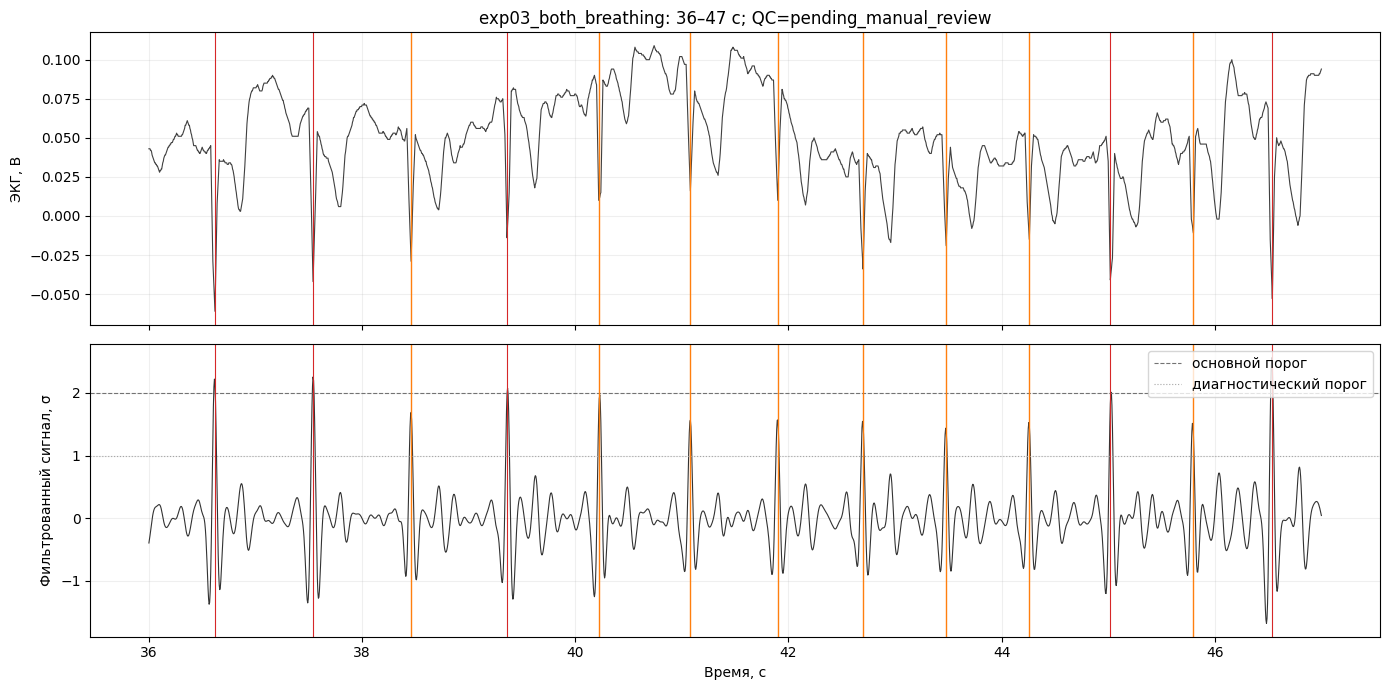

Основных кандидатов: 80
Добавлено диагностическим порогом: 8
Статус: pending_manual_review — автоматическое принятие запрещено


In [4]:
# Ручной просмотр и явное принятие или отклонение ЭКГ-разметки
CHECK_RECORD_ID = "exp03_both_breathing"
CHECK_WINDOW_S = (36.0, 47.0)
REVIEW_DECISION = None
# Пример:
# REVIEW_DECISION = {
#     "record_id": "<record_id>",
#     "status": "accepted",
#     "reviewer": "<reviewer>",
#     "accepted_rpeaks_s": [1.02, 1.84, 2.67],
#     "accepted_polarity": 1,  # 1 или -1
#     "notes": "<основание решения>",
# }


def validate_rpeaks(rpeaks_s, start_s, stop_s):
    values = np.asarray(rpeaks_s, dtype=float)
    if values.ndim != 1 or len(values) < 2 or not np.isfinite(values).all():
        raise ValueError("Нужны не менее двух конечных R-зубцов")
    if np.any(np.diff(values) <= 0):
        raise ValueError("R-зубцы должны быть уникальны и строго упорядочены")
    if values[0] < start_s or values[-1] > stop_s:
        raise ValueError("R-зубцы выходят за границы записи")
    return [float(value) for value in values]


def apply_review(decision):
    record_id = decision["record_id"]
    sidecar_path = OUT_DIR / f"{record_id}.json"
    annotation = json.loads(sidecar_path.read_text(encoding="utf-8"))
    source_path = resolve_record_path(annotation["input"]["relative_path"])
    if sha256_file(source_path) != annotation["input"]["sha256"]:
        raise RuntimeError("SHA-256 исходного CSV изменился после разметки")
    status = decision["status"]
    reviewer = str(decision.get("reviewer", "")).strip()
    if status not in {"accepted", "rejected"} or not reviewer:
        raise ValueError("Нужны статус accepted/rejected и имя проверяющего")

    accepted_rpeaks_s = None
    accepted_polarity = None
    model_windows = None
    if status == "accepted":
        frame = read_record(source_path)
        time = frame["time_s"].to_numpy(dtype=float)
        accepted_rpeaks_s = validate_rpeaks(
            decision.get("accepted_rpeaks_s"),
            float(time[0]),
            float(time[-1]),
        )
        accepted_polarity = decision.get("accepted_polarity")
        if accepted_polarity not in {-1, 1}:
            raise ValueError("accepted_polarity должен быть равен 1 или -1")
        model_windows = model_electrical_systole(accepted_rpeaks_s)

    reviewed_at = datetime.now(timezone.utc).isoformat()
    previous_qc = annotation.get("qc", {})
    history = list(previous_qc.get("history", []))
    history.append({
        "status": previous_qc.get("status"),
        "reviewer": previous_qc.get("reviewer"),
        "reviewed_at": previous_qc.get("reviewed_at"),
        "notes": previous_qc.get("notes"),
        "algorithm_version": annotation.get("algorithm_version"),
    })
    annotation["rpeaks_s"] = accepted_rpeaks_s
    annotation["accepted_polarity"] = accepted_polarity
    annotation["model_electrical_systole_s"] = model_windows
    annotation["qc"] = {
        "status": status,
        "reviewer": reviewer,
        "reviewed_at": reviewed_at,
        "notes": decision.get("notes"),
        "history": history,
    }
    sidecar_path.write_text(
        json.dumps(annotation, ensure_ascii=False, indent=2) + "\n",
        encoding="utf-8",
    )
    return annotation


if REVIEW_DECISION is not None:
    reviewed = apply_review(REVIEW_DECISION)
    print(reviewed["record_id"], reviewed["qc"]["status"])

if CHECK_RECORD_ID is None:
    print("Задайте CHECK_RECORD_ID для просмотра конкретной записи.")
else:
    annotation = json.loads(
        (OUT_DIR / f"{CHECK_RECORD_ID}.json").read_text(encoding="utf-8")
    )
    source_path = resolve_record_path(annotation["input"]["relative_path"])
    if sha256_file(source_path) != annotation["input"]["sha256"]:
        raise RuntimeError("SHA-256 исходного CSV изменился")
    frame = read_record(source_path)
    time = frame["time_s"].to_numpy(dtype=float)
    raw = frame["ecg_v"].to_numpy(dtype=float)
    fs_hz, _ = sampling_frequency(frame)
    _, normalized, polarity = filtered_ecg(raw, fs_hz)

    start_s, stop_s = (
        CHECK_WINDOW_S
        if CHECK_WINDOW_S is not None
        else (float(time[0]), float(time[-1]))
    )
    if not float(time[0]) <= start_s < stop_s <= float(time[-1]):
        raise ValueError("CHECK_WINDOW_S выходит за границы записи")
    mask = (time >= start_s) & (time <= stop_s)
    strict_times = annotation["candidate_rpeaks_s"]
    added_times = annotation["diagnostic_lower_threshold"]["added_rpeaks_s"]

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    axes[0].plot(time[mask], raw[mask], color="0.25", linewidth=0.8)
    axes[0].set_ylabel("ЭКГ, В")
    axes[1].plot(
        time[mask],
        polarity * normalized[mask],
        color="0.20",
        linewidth=0.8,
    )
    axes[1].axhline(
        PARAMETERS["peak_height_z"],
        color="0.45",
        linewidth=0.8,
        linestyle="--",
        label="основной порог",
    )
    axes[1].axhline(
        annotation["diagnostic_lower_threshold"]["height_z"],
        color="0.65",
        linewidth=0.8,
        linestyle=":",
        label="диагностический порог",
    )
    for axis in axes:
        for r_time in strict_times:
            if start_s <= r_time <= stop_s:
                axis.axvline(r_time, color="tab:red", linewidth=0.8)
        for r_time in added_times:
            if start_s <= r_time <= stop_s:
                axis.axvline(r_time, color="tab:orange", linewidth=1.0)
        axis.grid(alpha=0.2)
    axes[1].legend(loc="upper right")
    axes[1].set_xlabel("Время, с")
    axes[1].set_ylabel("Фильтрованный сигнал, σ")
    axes[0].set_title(
        f"{CHECK_RECORD_ID}: {start_s:g}–{stop_s:g} с; "
        f"QC={annotation['qc']['status']}"
    )
    plt.tight_layout()
    plt.show()

    print("Основных кандидатов:", len(strict_times))
    print("Добавлено диагностическим порогом:", len(added_times))
    print(
        "Статус:",
        annotation["qc"]["status"],
        "— автоматическое принятие запрещено",
    )